<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/14%EC%9E%A5_(2)Prophet_%EC%A3%BC%EA%B0%80%EC%98%88%EC%B8%A1%EB%B6%84%EC%84%9D_2026_04_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝분석_(2)Prophet_주가 예측

### * Prophet 라이브러리를 사용하여 100일 후 주가 예측하기

# 1. 데이터 수집

In [1]:
import pandas as pd

In [3]:
# 14장 프로젝트(1)주가분석 에서 저장해둔 구글 주가 데이터 파일 읽어오기
stock = pd.read_csv('GOOG.csv')

# 2. 데이터 준비 및 탐색

### - 데이터 정보 확인

In [4]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    899 non-null    object 
 1   GOOG    899 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.2+ KB


### - 데이터 확인

In [5]:
stock.head()

,Date,GOOG
0,2021-01-04,85.708336
1,2021-01-05,86.337173
2,2021-01-06,86.057983
3,2021-01-07,88.634819
4,2021-01-08,89.624687


### - Prophet 모델의 입력 조건에 따라 열이름 변경

In [6]:
stock.columns = ['ds', 'y']

In [7]:
stock.head()  #작업 확인용 출력

,ds,y
0,2021-01-04,85.708336
1,2021-01-05,86.337173
2,2021-01-06,86.057983
3,2021-01-07,88.634819
4,2021-01-08,89.624687


# 2. 분석 모델 구축

In [8]:
# Prophet 라이브러리 임포트
from prophet  import Prophet

## 1) Prophet 모델 생성

In [9]:
# Prophet 모델 객체 생성
Pp_stock = Prophet()

## 2) Prophet 모델의 학습

In [10]:
# Prophet 모델 학습하기
Pp_stock.fit(stock)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## 3) 100일 후 예측하기

### - 예측 작업을 위한 데이터 프레임의 ds(날짜) 생성

In [11]:
# 100일후 주가 예측을 위해 날짜 데이터프레임 준비하기
future_ds = Pp_stock.make_future_dataframe(periods=100)

future_ds.tail()  #작업 확인용 출력

,ds
994,2024-11-04
995,2024-11-05
996,2024-11-06
997,2024-11-07
998,2024-11-08


In [12]:
future_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      999 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


### - 미래 날짜에 대한 예측값(y) 생성

In [13]:
# 미래 날짜(ds)에 대한 예측값(y) 생성
future_y = Pp_stock.predict(future_ds)

# 작업 확인용 출력
future_y[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
994,2024-11-04,194.707356,186.915460,202.082860
995,2024-11-05,194.866088,188.326187,202.060494
996,2024-11-06,195.119184,187.943157,202.410242
997,2024-11-07,195.474444,187.845791,202.952969
998,2024-11-08,195.913109,188.597541,203.186461


# 3. 결과 분석 및 시각화

### 1) 결과 시각화

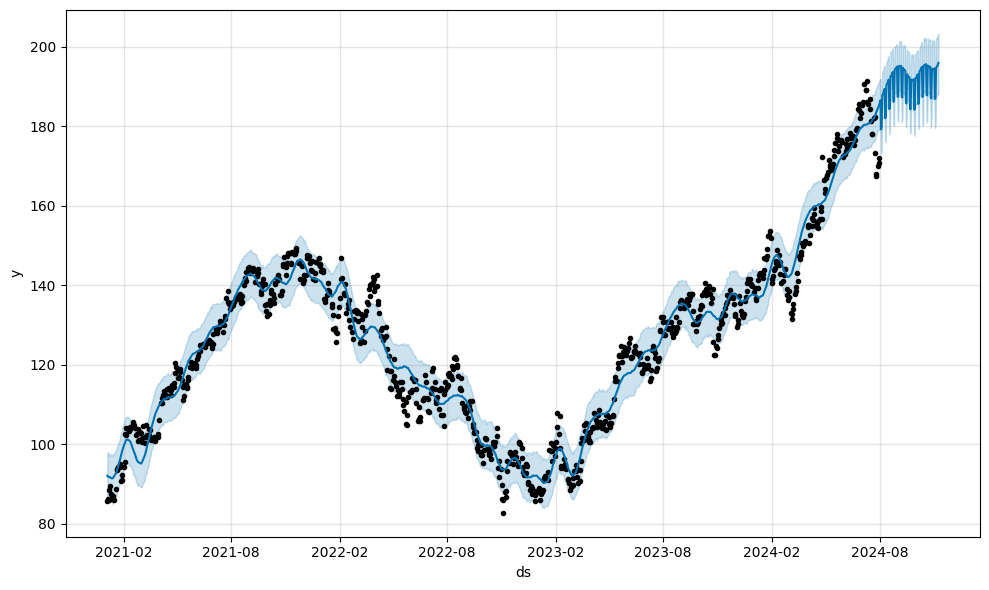

In [14]:
# 예측 분석 결과 시각화하기
fig_trend = Pp_stock.plot(future_y)

### - Prophet의 트랜드와 계절성(weekly, yearly) 기준 시각화

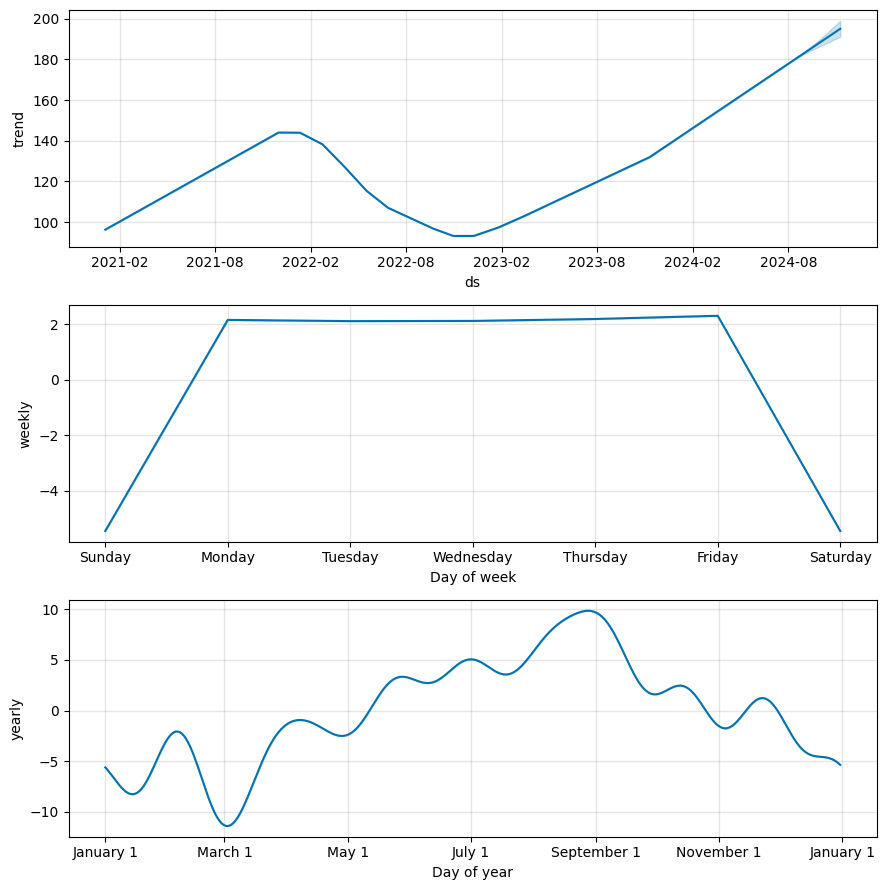

In [15]:
# 분석 컴포넌트 그래프
fig_components = Pp_stock.plot_components(future_y)

### 2) 트랜드 변화 시점 추가 시각화

In [16]:
from prophet.plot import add_changepoints_to_plot

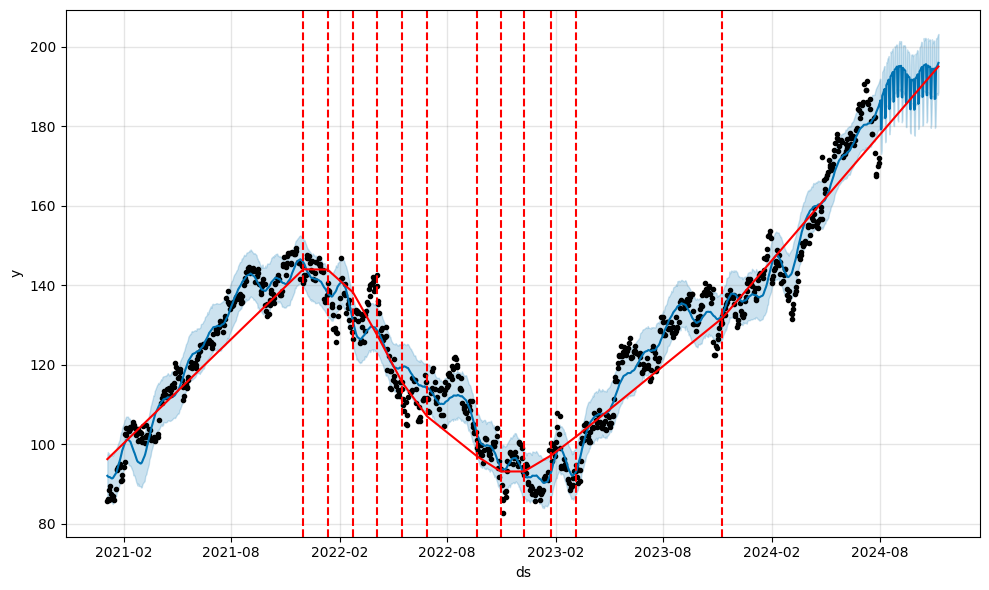

In [17]:
fig_trend = Pp_stock.plot(future_y)
fig_trend_changepoints = add_changepoints_to_plot(fig_trend.gca(), Pp_stock, future_y)

### 3) Prophet의 트랜드와 계절성(weekly, yearly) 기준 대화형 시각화

#### - Prophet 대화형 시각화 모듈 임포트

In [18]:
# Prophet plot 모듈 임포트
from prophet.plot import plot_plotly, plot_components_plotly

#### - Prophet 대화형 시각화

In [19]:
# 대화형 시각화 - 트랜드
plot_plotly(Pp_stock, future_y)

In [20]:
# 대화형 시각화 - 트랜드, 연 계절성, 주 계절성
plot_components_plotly(Pp_stock, future_y)

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.

